In [17]:
import numpy as np
import matplotlib.pyplot as plt
import os
join = os.path.join
from tqdm import tqdm
import torch
import torchvision
from torch.utils.data import Dataset, DataLoader
import monai
from segment_anything import SamPredictor, sam_model_registry
from segment_anything.utils.transforms import ResizeLongestSide
# from utils.SurfaceDice import compute_dice_coefficient Ne fonctionne pas 
import skimage
# set seeds
torch.manual_seed(2023)
np.random.seed(2023)

In [56]:
# MOI ajout des imports qui sont partout dans le doc ici : 
import tarfile
import nibabel as nib
import glob
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact
import seaborn as sns

In [ ]:
#If your data is .tar format, you can run this cell to extract it
'''
# import tarfile localisation initiale 
file = tarfile.open('./BraTS2021_Training_Data.tar')
file.extractall('./brain_images')
file.close()
'''

In [21]:
# Read scans and ground-truth masks with .nii.gz format O

# import nibabel as nib loc originale, mis plus haut 

# Chemins vers les fichiers .nii 
# MOI ici les fichiers sont hardcodés, maybe mettre du code plus reproductible ? 
scan_path = "./data/BraTS2021_00495_t2.nii.gz"
gt_path =   "./data/BraTS2021_00495_seg.nii.gz"

# Originaux 
#scan_path = "./brain_images/BraTS2021_00002/BraTS2021_00002_t2.nii.gz" # image médicale (IRM)
#gt_path = "./brain_images/BraTS2021_00002/BraTS2021_00002_seg.nii.gz"  # gt pour ground truth = segmentation correspondante

# Load les fichiers 
scan_obj = nib.load(scan_path)
gt_obj = nib.load(gt_path)

# Validation je pense 
type(scan_obj) 

scan_data = scan_obj.get_fdata()
print(type(scan_data))
scan_data.shape

gt_data = gt_obj.get_fdata()
print(type(gt_data))
gt_data.shape


<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


(240, 240, 155)

In [22]:
#Visualize scans in interactive way, use sliding bar to specify slices
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact
def visualize_3d_scan(layer):
    plt.figure(figsize=(10, 5))
    plt.imshow(scan_data[:, :, layer], cmap='gray')
    plt.axis('off')
    return layer

def visualize_3d_gt(layer):
    plt.figure(figsize=(10, 5))
    plt.imshow(gt_data[:, :, layer], cmap='gray')
    plt.axis('off')
    return layer
interact(visualize_3d_scan, layer=(0, scan_data.shape[2] - 1))
interact(visualize_3d_gt, layer=(0, gt_data.shape[2] - 1))

interactive(children=(IntSlider(value=77, description='layer', max=154), Output()), _dom_classes=('widget-inte…

interactive(children=(IntSlider(value=77, description='layer', max=154), Output()), _dom_classes=('widget-inte…

<function __main__.visualize_3d_gt(layer)>

In [23]:
#Choose a 2D slice to feed into SAM model
slice_index = 106
def get_slice_pair(layer):
    return scan_data[:, :, layer],gt_data[:, :, layer]
scan_2d,gt_2d = get_slice_pair(slice_index)
ori_scan_2d = scan_2d

In [24]:
#re-format to match required shape of SAM input
if scan_2d.shape[-1]>3 and len(scan_2d.shape)==3:
    scan_2d = scan_2d[:,:,:3]
if len(scan_2d.shape)==2:
    scan_2d = np.repeat(scan_2d[:,:,None], 3, axis=-1)

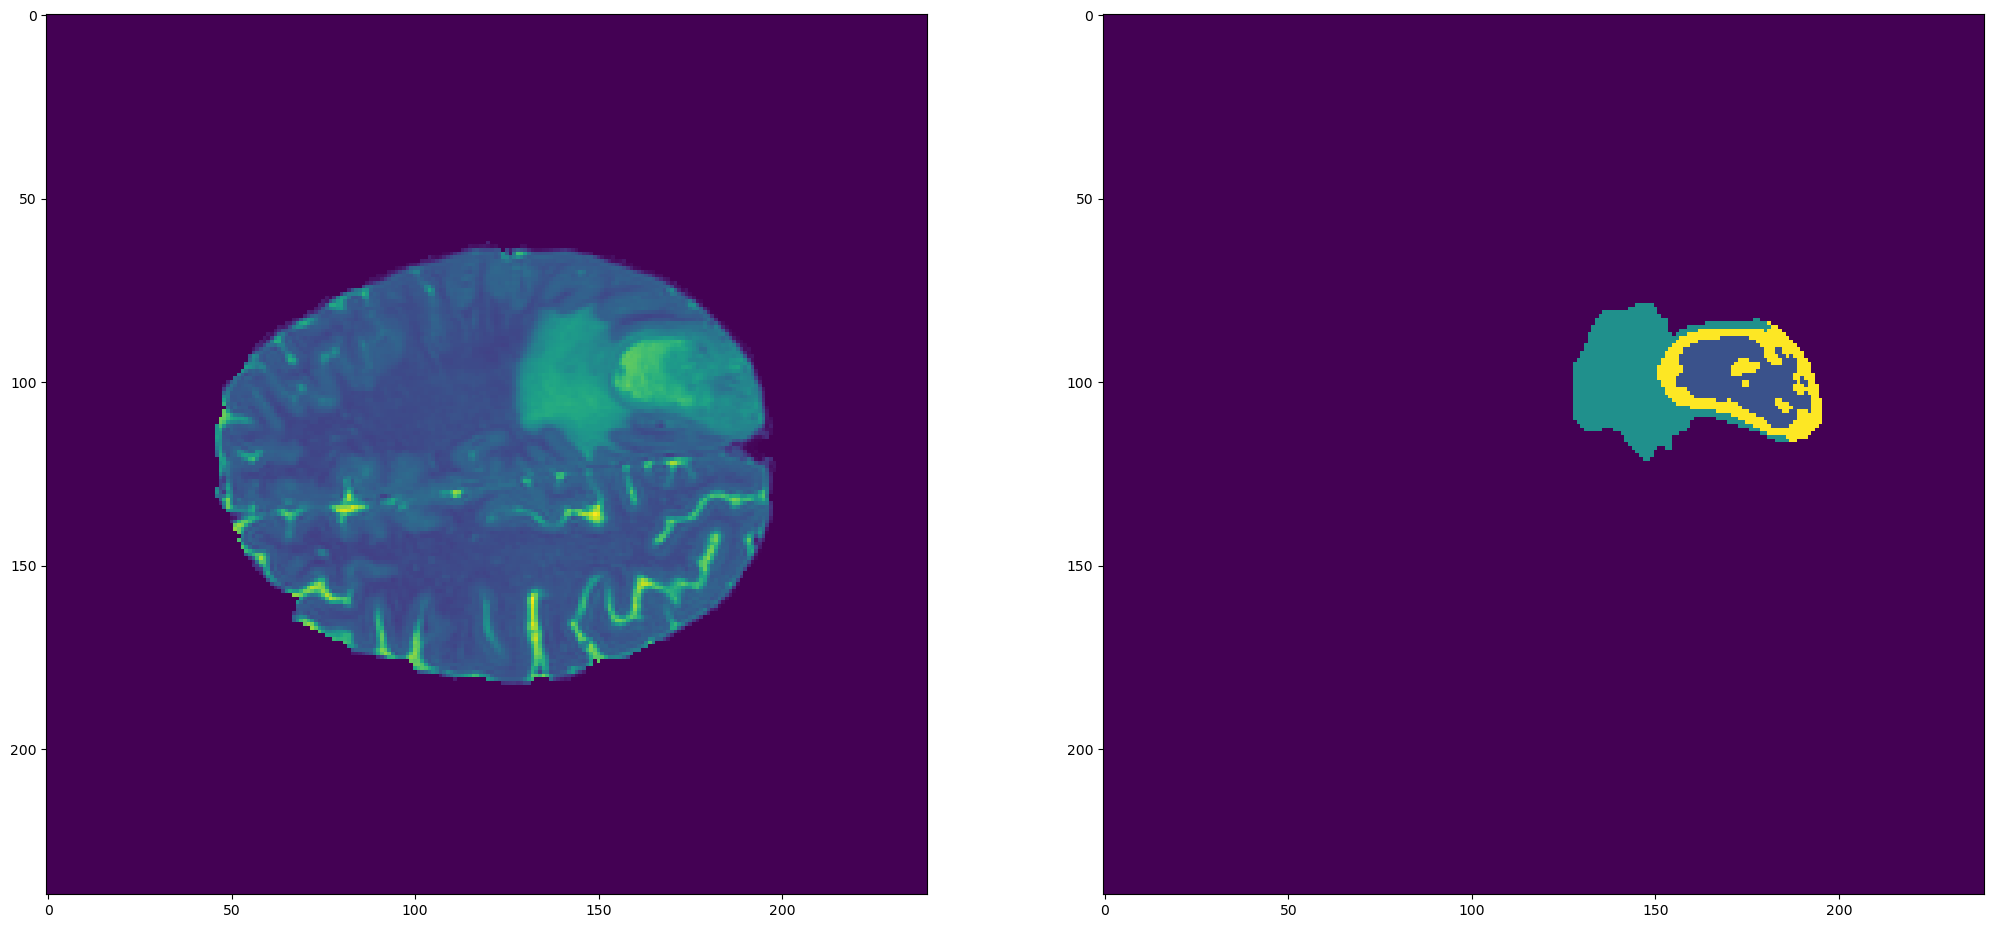

In [25]:
#Visualize the original MRI slice and corresponding mask
_, axs = plt.subplots(1, 2, figsize=(25, 25))
axs[0].imshow(ori_scan_2d)
axs[1].imshow(gt_2d)
plt.show() 
plt.close()

In [26]:
#Return a bounding box from ground-truth, this bounding box will be used as a prompt when inferencing
def get_bbox_from_mask(mask):
    '''Returns a bounding box from a mask'''
    y_indices, x_indices = np.where(mask > 0)
    x_min, x_max = np.min(x_indices), np.max(x_indices)
    y_min, y_max = np.min(y_indices), np.max(y_indices)
    # add perturbation to bounding box coordinates
    H, W = mask.shape
    x_min = max(0, x_min - np.random.randint(0, 20))
    x_max = min(W, x_max + np.random.randint(0, 20))
    y_min = max(0, y_min - np.random.randint(0, 20))
    y_max = min(H, y_max + np.random.randint(0, 20))

    return np.array([x_min, y_min, x_max, y_max])
bbox_raw = get_bbox_from_mask(gt_2d)
print(bbox_raw.shape)

(4,)


In [27]:
#Load pre-trained model checkpoint and do simple pre-processing
model_type = 'vit_b'

sam_model_checkpoint = './models/sam_vit_b_01ec64.pth'
med_sam_model_checkpoint = './models/sam_model_best.pth' # Not the original but matches the link 

In [28]:
# Changé vu que je n'ai pas de GPU, tout les devices étaient cuda (GPU) donc je change pour cpu
device = torch.device('cpu')

sam_model = sam_model_registry[model_type](checkpoint=None)
sam_model.load_state_dict(torch.load(sam_model_checkpoint, map_location=torch.device('cpu')))
sam_model.to(device)

med_sam_model = sam_model_registry[model_type](checkpoint=None)
med_sam_model.load_state_dict(torch.load(med_sam_model_checkpoint, map_location=torch.device('cpu')))
med_sam_model.to(device)

sam_predictor = SamPredictor(sam_model)
med_sam_predictor = SamPredictor(med_sam_model)

In [30]:
lower_bound, upper_bound = np.percentile(scan_2d, 0.5), np.percentile(scan_2d, 99.5)
scan_2d_pre = np.clip(scan_2d, lower_bound, upper_bound)
scan_2d_pre = (scan_2d_pre - np.min(scan_2d_pre))/(np.max(scan_2d_pre)-np.min(scan_2d_pre))*255.0
scan_2d_pre[scan_2d==0] = 0
scan_2d_pre = np.uint8(scan_2d_pre)
H, W, _ = scan_2d_pre.shape

# predict the segmentation mask using the original SAM model
sam_predictor.set_image(scan_2d_pre)
sam_seg, _, _ = sam_predictor.predict(point_coords=None, box=bbox_raw, multimask_output=False)
print(sam_seg.shape)

(1, 240, 240)


In [14]:
#Load pre-trained model checkpoint and do simple pre-processing

# Original : 

'''
model_type = 'vit_b'
sam_model_checkpoint = './sam_vit_b_01ec64.pth'
med_sam_model_checkpoint = './med_sam_model_best.pth' #you can find my pre-traind checkpoint file from: https://drive.google.com/drive/folders/1MbHo0qBfkQYARUhB-DAhbD5a4lhmYNqs?usp=drive_link
device = 'cuda:0'
sam_model = sam_model_registry[model_type](checkpoint=sam_model_checkpoint).to(device)
med_sam_model = sam_model_registry[model_type](checkpoint=med_sam_model_checkpoint).to(device)
sam_predictor = SamPredictor(sam_model)
med_sam_predictor = SamPredictor(med_sam_model)


lower_bound, upper_bound = np.percentile(scan_2d, 0.5), np.percentile(scan_2d, 99.5)
scan_2d_pre = np.clip(scan_2d, lower_bound, upper_bound)
scan_2d_pre = (scan_2d_pre - np.min(scan_2d_pre))/(np.max(scan_2d_pre)-np.min(scan_2d_pre))*255.0
scan_2d_pre[scan_2d==0] = 0
scan_2d_pre = np.uint8(scan_2d_pre)
H, W, _ = scan_2d_pre.shape

# predict the segmentation mask using the original SAM model
sam_predictor.set_image(scan_2d_pre)
sam_seg, _, _ = sam_predictor.predict(point_coords=None, box=bbox_raw, multimask_output=False)
print(sam_seg.shape)
'''

"\nmodel_type = 'vit_b'\nsam_model_checkpoint = './sam_vit_b_01ec64.pth'\nmed_sam_model_checkpoint = './med_sam_model_best.pth' #you can find my pre-traind checkpoint file from: https://drive.google.com/drive/folders/1MbHo0qBfkQYARUhB-DAhbD5a4lhmYNqs?usp=drive_link\ndevice = 'cuda:0'\nsam_model = sam_model_registry[model_type](checkpoint=sam_model_checkpoint).to(device)\nmed_sam_model = sam_model_registry[model_type](checkpoint=med_sam_model_checkpoint).to(device)\nsam_predictor = SamPredictor(sam_model)\nmed_sam_predictor = SamPredictor(med_sam_model)\n\n\nlower_bound, upper_bound = np.percentile(scan_2d, 0.5), np.percentile(scan_2d, 99.5)\nscan_2d_pre = np.clip(scan_2d, lower_bound, upper_bound)\nscan_2d_pre = (scan_2d_pre - np.min(scan_2d_pre))/(np.max(scan_2d_pre)-np.min(scan_2d_pre))*255.0\nscan_2d_pre[scan_2d==0] = 0\nscan_2d_pre = np.uint8(scan_2d_pre)\nH, W, _ = scan_2d_pre.shape\n\n# predict the segmentation mask using the original SAM model\nsam_predictor.set_image(scan_2d_pr

In [31]:
#Fine-tuned model predictions
med_sam_transform = ResizeLongestSide(med_sam_model.image_encoder.img_size)
resize_img = med_sam_transform.apply_image(scan_2d_pre)
resize_img_tensor = torch.as_tensor(resize_img.transpose(2, 0, 1)).to(device)
input_image = med_sam_model.preprocess(resize_img_tensor[None,:,:,:]) # (1, 3, 1024, 1024)
assert input_image.shape == (1, 3, med_sam_model.image_encoder.img_size, med_sam_model.image_encoder.img_size), 'input image should be resized to 1024*1024'

with torch.no_grad():
    # pre-compute the image embedding
    ts_img_embedding = med_sam_model.image_encoder(input_image)
    # convert box to 1024x1024 grid
    bbox = med_sam_transform.apply_boxes(bbox_raw, (H, W))
    print(f'{bbox_raw=} -> {bbox=}')
    box_torch = torch.as_tensor(bbox, dtype=torch.float, device=device)
    if len(box_torch.shape) == 2:
        box_torch = box_torch[:, None, :] # (B, 4) -> (B, 1, 4)
    
    sparse_embeddings, dense_embeddings = med_sam_model.prompt_encoder(
        points=None,
        boxes=box_torch,
        masks=None,
    )
    medsam_seg_prob, _ = med_sam_model.mask_decoder(
        image_embeddings=ts_img_embedding.to(device), # (B, 256, 64, 64)
        image_pe=med_sam_model.prompt_encoder.get_dense_pe(), # (1, 256, 64, 64)
        sparse_prompt_embeddings=sparse_embeddings, # (B, 2, 256)
        dense_prompt_embeddings=dense_embeddings, # (B, 256, 64, 64)
        multimask_output=False,
        )
    medsam_seg_prob = torch.sigmoid(medsam_seg_prob)
    # convert soft mask to hard mask
    medsam_seg_prob = medsam_seg_prob.cpu().numpy().squeeze()
    medsam_seg = (medsam_seg_prob > 0.5).astype(np.uint8)

    medsam_seg = skimage.transform.resize(medsam_seg,(240,240))
    medsam_seg = skimage.util.img_as_ubyte(medsam_seg)
    print(medsam_seg.shape)
    print(medsam_seg)
    


bbox_raw=array([122,  76, 196, 126]) -> bbox=array([[520.53333333, 324.26666667, 836.26666667, 537.6       ]])
(240, 240)
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [47]:
def compute_dice_coefficient(mask_gt, mask_pred):
    volume_sum = mask_gt.sum() + mask_pred.sum()  # |A| + |B| → nb de pixels dans chaque masque
    if volume_sum == 0:
        return 1.0                                 # cas spécial : les deux masques sont vides
    volume_intersect = (mask_gt & mask_pred).sum() # |A ∩ B| → pixels en commun
    return 2 * volume_intersect / volume_sum       # formule DICE

In [46]:
# Compréhension : 

# Les masques de tumeurs 
print("ground truth", np.unique(gt_2d))
print("predicted", np.unique(sam_seg))
print("predicted", np.unique(medsam_seg))

'''
Pour le masque ground truth, il y a plusieurs valeurs qui sont je pense le type la région 

Annotations comprise the GD-enhancing tumor (ET — label 4), the peritumoral edematous/invaded tissue (ED — label 2), 
and the necrotic tumor core (NCR — label 1), as described both in the BraTS 2012-2013 TMI paper and in the latest 
BraTS summarizing paper. 

Mais nous on prédit juste la tumeur en général, donc on veut juste les valeurs > 0 

C'est pour ça que quand il les plogue il met gt_2d>0

'''
print("ground truth", np.unique(gt_2d>0))

ground truth [0. 1. 2. 4.]
predicted [False  True]
predicted [0 1]
ground truth [False  True]


In [48]:
#Compute DICE score on both original and fine-tuned models
#from utils.SurfaceDice import compute_dice_coefficient
#from utils.SurfaceDice import compute_dice_coefficient

sam_dsc = compute_dice_coefficient(gt_2d>0, sam_seg>0)
medsam_dsc = compute_dice_coefficient(gt_2d>0, medsam_seg>0)
print('Original SAM DSC: {:.4f}'.format(sam_dsc), 'MedSAM DSC: {:.4f}'.format(medsam_dsc))

Original SAM DSC: 0.9124 MedSAM DSC: 0.9161


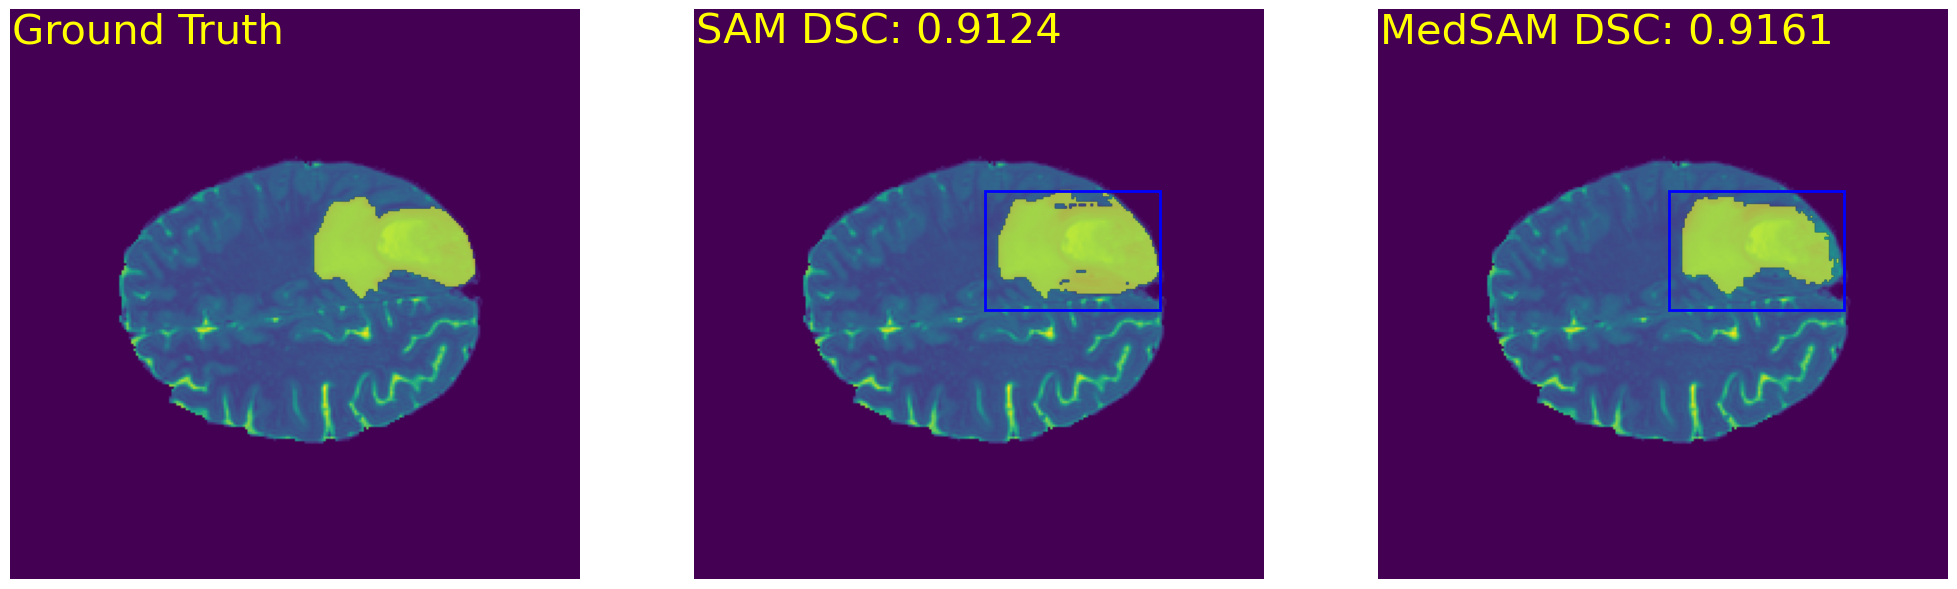

In [49]:
#%% visualize the segmentation results of the middle slice
# visualization functions
# source: https://github.com/facebookresearch/segment-anything/blob/main/notebooks/predictor_example.ipynb
# change color to avoid red and green
def show_mask(mask, ax, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([251/255, 252/255, 30/255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)
    
def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='blue', facecolor=(0,0,0,0), lw=2))    

_, axs = plt.subplots(1, 3, figsize=(25, 25))
#scan_2d,gt_2d
axs[0].imshow(ori_scan_2d)
show_mask(gt_2d>0, axs[0])
# show_box(box_np[img_id], axs[0])
# axs[0].set_title('Mask with Tuned Model', fontsize=20)
axs[0].axis('off')
axs[0].text(0.5, 0.5, 'Ground Truth', fontsize=30, horizontalalignment='left', verticalalignment='top', color='yellow')
axs[1].imshow(ori_scan_2d)
show_mask(sam_seg, axs[1])
show_box(bbox_raw, axs[1])
# add text to image to show dice score
axs[1].text(0.5, 0.5, 'SAM DSC: {:.4f}'.format(sam_dsc), fontsize=30, horizontalalignment='left', verticalalignment='top', color='yellow')
# axs[1].set_title('Mask with Untuned Model', fontsize=20)
axs[1].axis('off')

axs[2].imshow(ori_scan_2d)
show_mask(medsam_seg, axs[2])
show_box(bbox_raw, axs[2])
# add text to image to show dice score
axs[2].text(0.5, 0.5, 'MedSAM DSC: {:.4f}'.format(medsam_dsc), fontsize=30, horizontalalignment='left', verticalalignment='top', color='yellow')
# axs[2].set_title('Ground Truth', fontsize=20)
axs[2].axis('off')
plt.show()  
plt.subplots_adjust(wspace=0.01, hspace=0)
# save plot
# plt.savefig(join(model_save_path, test_npzs[npz_idx].split('.npz')[0] + str(img_id).zfill(3) + '.png'), bbox_inches='tight', dpi=300)
plt.close()

In [50]:
import glob
#Functions to get two dice score of both models
def get_2_dice_scores_of_scan(image,gt):
    ##SAM original
    lower_bound, upper_bound = np.percentile(image, 0.5), np.percentile(image, 99.5)
    image_pre = np.clip(image, lower_bound, upper_bound)
    image_pre = (image_pre - np.min(image_pre))/(np.max(image_pre)-np.min(image_pre))*255.0
    image_pre[image==0] = 0
    image_pre = np.uint8(image_pre)
    H, W, _ = image_pre.shape

    # predict the segmentation mask using the original SAM model
    sam_predictor.set_image(image_pre)
    sam_seg, _, _ = sam_predictor.predict(point_coords=None, box=bbox_raw, multimask_output=False)
    
    ##Fine-tuned SAM

    med_sam_transform = ResizeLongestSide(med_sam_model.image_encoder.img_size)
    resize_img = med_sam_transform.apply_image(image_pre)
    resize_img_tensor = torch.as_tensor(resize_img.transpose(2, 0, 1)).to(device)
    input_image = med_sam_model.preprocess(resize_img_tensor[None,:,:,:]) # (1, 3, 1024, 1024)
    assert input_image.shape == (1, 3, med_sam_model.image_encoder.img_size, med_sam_model.image_encoder.img_size), 'input image should be resized to 1024*1024'

    with torch.no_grad():
        # pre-compute the image embedding
        ts_img_embedding = med_sam_model.image_encoder(input_image)
        # convert box to 1024x1024 grid
        bbox = med_sam_transform.apply_boxes(bbox_raw, (H, W))
        #print(f'{bbox_raw=} -> {bbox=}')
        box_torch = torch.as_tensor(bbox, dtype=torch.float, device=device)
        if len(box_torch.shape) == 2:
            box_torch = box_torch[:, None, :] # (B, 4) -> (B, 1, 4)
        
        sparse_embeddings, dense_embeddings = med_sam_model.prompt_encoder(
            points=None,
            boxes=box_torch,
            masks=None,
        )
        medsam_seg_prob, _ = med_sam_model.mask_decoder(
            image_embeddings=ts_img_embedding.to(device), # (B, 256, 64, 64)
            image_pe=med_sam_model.prompt_encoder.get_dense_pe(), # (1, 256, 64, 64)
            sparse_prompt_embeddings=sparse_embeddings, # (B, 2, 256)
            dense_prompt_embeddings=dense_embeddings, # (B, 256, 64, 64)
            multimask_output=False,
            )
        medsam_seg_prob = torch.sigmoid(medsam_seg_prob)
        # convert soft mask to hard mask
        medsam_seg_prob = medsam_seg_prob.cpu().numpy().squeeze()
        medsam_seg = (medsam_seg_prob > 0.5).astype(np.uint8)
    
        medsam_seg = skimage.transform.resize(medsam_seg,(240,240))
        medsam_seg = skimage.util.img_as_ubyte(medsam_seg)


    sam_dsc = compute_dice_coefficient(gt_2d>0, sam_seg>0)
    medsam_dsc = compute_dice_coefficient(gt_2d>0, medsam_seg>0)

    return sam_dsc,medsam_dsc



In [65]:
scan_path_list = [file for file in scan_path_list if file.endswith("t2.nii.gz")]

NameError: name 'scan_path_list' is not defined

In [70]:
# MOI je debug live il y a plus l'original 

"""
Ici test avec une structure différente 
"""

#Go through entire scan folder, obtain random slice from each scan, then compute their dice score

def get_statistic_socre_on_dataset(data_path):
    sam_scores_array = []
    medsam_scores_array = []
    scan_path_list = glob.glob(data_path+"/*")
    print(scan_path_list)
    scan_path_list = [file for file in scan_path_list if file.endswith("t2.nii.gz")]
    print(scan_path_list)

    for scan_path in scan_path_list:
      #print(scan_path)
      #scan_data_list = glob.glob(scan_path+"/*")
      #print(scan_data_list)
      image = nib.load(scan_path).get_fdata() #t2 for example ICI ct 4 mais moi j'ai juste mis les t2 donc je vais mettre 0
      gt =  nib.load(scan_path.replace('t2.nii.gz', 'seg.nii.gz')).get_fdata()

      print(image) 
        
      slice_index = np.random.randint(10,140)
      image,gt = get_slice_pair(slice_index)

      if image.shape[-1]>3 and len(image.shape)==3:
        image = image[:,:,:3]
      if len(image.shape)==2:
        image = np.repeat(image[:,:,None], 3, axis=-1)
    
      sam_score, medsam_score =  get_2_dice_scores_of_scan(image,gt)
      sam_scores_array.append(sam_score)
      medsam_scores_array.append(medsam_score)
      #print(type(image))
      #print(gt.shape)
    
    sam_scores_array = np.array(sam_scores_array)
    medsam_scores_array = np.array(medsam_scores_array)
    print(np.average(sam_scores_array))
    print(np.average(medsam_scores_array))
    return sam_scores_array,medsam_scores_array

        
sam_scores_array, medsam_scores_array = get_statistic_socre_on_dataset("./data")   

['./data/BraTS2021_00621_seg.nii.gz', './data/BraTS2021_00621_t2.nii.gz', './data/BraTS2021_00495_seg.nii.gz', './data/BraTS2021_00495_t2.nii.gz']
['./data/BraTS2021_00621_t2.nii.gz', './data/BraTS2021_00495_t2.nii.gz']
[[[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 ...

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0.

In [61]:
# MOI je debug live il y a plus l'original 

"""
Je crois que ça marche pas pcq on a pas la même structure, si je fais un data_test avec des sous dossier sujets?
Avant de tout changer je vais attendre voir la structure de la grosse basse de données 
"""

#Go through entire scan folder, obtain random slice from each scan, then compute their dice score

def get_statistic_socre_on_dataset(data_path):
    sam_scores_array = []
    medsam_scores_array = []
    scan_path_list = glob.glob(data_path+"/*")
    print(scan_path_list)
    
    for scan_path in scan_path_list:
      print(scan_path)
      scan_data_list = glob.glob(scan_path+"/*")
      print(scan_data_list)
      image = nib.load(scan_data_list[4]).get_fdata() #t2 for example ICI ct 4 mais moi j'ai juste mis les t2 donc je vais mettre 0
      gt =  nib.load(scan_data_list[1]).get_fdata()
      slice_index = np.random.randint(10,140)
      image,gt = get_slice_pair(slice_index)
        
      if image.shape[-1]>3 and len(image.shape)==3:
        image = image[:,:,:3]
      if len(image.shape)==2:
        image = np.repeat(image[:,:,None], 3, axis=-1)
    
      sam_score, medsam_score =  get_2_dice_scores_of_scan(image,gt)
      sam_scores_array.append(sam_score)
      medsam_scores_array.append(medsam_score)
      #print(type(image))
      #print(gt.shape)
    sam_scores_array = np.array(sam_scores_array)
    medsam_scores_array = np.array(medsam_scores_array)
    print(np.average(sam_scores_array))
    print(np.average(medsam_scores_array))
    return sam_scores_array,medsam_scores_array
   
sam_scores_array, medsam_scores_array = get_statistic_socre_on_dataset("./data")   

['./data/BraTS2021_00621_seg.nii.gz', './data/BraTS2021_00621_t2.nii.gz', './data/BraTS2021_00495_seg.nii.gz', './data/BraTS2021_00495_t2.nii.gz']
./data/BraTS2021_00621_seg.nii.gz
[]


IndexError: list index out of range

<Axes: >

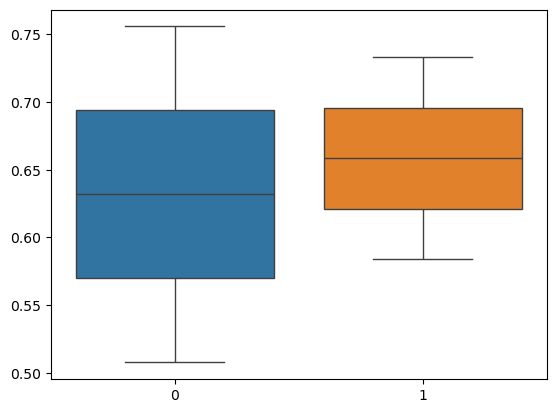

In [71]:
#visualize the dice socre array of original SAM and fine-tuned SAM
all_arr = [sam_scores_array,medsam_scores_array]
sns.boxplot(data=all_arr)